# Sentiment Analysis of TransJakarta App Reviews Using Machine Learning

This project analyzes user reviews from the TransJakarta mobile application on Google Play Store using Natural Language Processing (NLP) and machine learning techniques.

In [4]:
!pip install google-play-scraper pandas openpyxl -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
from google_play_scraper import reviews_all, Sort

## Objective

The objective of this project is to classify user reviews into positive and negative sentiments and compare the performance of multiple machine learning models.

In [6]:
app_id = "com.transjakmobile"

In [7]:
result = reviews_all(
    app_id,
    sleep_milliseconds=0,
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

## Data Collection

A total of 4,364 user reviews were collected from Google Play Store using the `google-play-scraper` library.

In [8]:
df = pd.DataFrame(result)

print("Jumlah data hasil crawling:", len(df))
df.head()

Jumlah data hasil crawling: 4414


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,bd54ccfb-3501-429d-8588-446e84586300,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk nya bagusss bikinn saya mudah transportasi,5,0,2.10.2,2026-05-05 09:22:41,None,NaT,2.10.2
1,13d0941d-ba49-41ed-9798-66c12188d27e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"""Transjakarta sangat memuaskan! Perjalanan cep...",5,0,2.10.2,2026-05-05 07:24:26,None,NaT,2.10.2
2,0864dcc2-b629-4f11-9afd-1d37bbd265bc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Transjakarta app-nya keren banget, memudahkan ...",5,0,None,2026-05-05 07:13:36,None,NaT,None
3,283867ed-5962-480f-84a2-0d905657e9cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Transjakarta punya aplikasi yang oke banget, i...",5,0,None,2026-05-05 07:09:20,None,NaT,None
4,f390a7ab-dcb1-4817-9cc4-98f91d0caf9b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi yang sangat rekomended buat memudahka...,5,0,None,2026-05-05 07:08:04,None,NaT,None


In [9]:
df = df[[
    'reviewId',
    'userName',
    'score',
    'content',
    'at',
    'thumbsUpCount',
    'appVersion'
]]
df.head()

,reviewId,userName,score,content,at,thumbsUpCount,appVersion
0,bd54ccfb-3501-429d-8588-446e84586300,Pengguna Google,5,apk nya bagusss bikinn saya mudah transportasi,2026-05-05 09:22:41,0,2.10.2
1,13d0941d-ba49-41ed-9798-66c12188d27e,Pengguna Google,5,"""Transjakarta sangat memuaskan! Perjalanan cep...",2026-05-05 07:24:26,0,2.10.2
2,0864dcc2-b629-4f11-9afd-1d37bbd265bc,Pengguna Google,5,"Transjakarta app-nya keren banget, memudahkan ...",2026-05-05 07:13:36,0,None
3,283867ed-5962-480f-84a2-0d905657e9cd,Pengguna Google,5,"Transjakarta punya aplikasi yang oke banget, i...",2026-05-05 07:09:20,0,None
4,f390a7ab-dcb1-4817-9cc4-98f91d0caf9b,Pengguna Google,5,Aplikasi yang sangat rekomended buat memudahka...,2026-05-05 07:08:04,0,None


In [10]:
df.to_csv("01_ulasan_transjakarta_raw.csv", index=False, encoding="utf-8-sig")
df.to_excel("01_ulasan_transjakarta_raw.xlsx", index=False)

print("Data mentah berhasil disimpan.")

Data mentah berhasil disimpan.


In [11]:
df['at'] = pd.to_datetime(df['at'])
print(df.dtypes)

reviewId                 object
userName                 object
score                     int64
content                  object
at               datetime64[ns]
thumbsUpCount             int64
appVersion               object
dtype: object


In [12]:
start_date = '2022-01-01'
end_date = '2026-12-31'

df = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

print("Jumlah data setelah filter tanggal:", len(df))
df.head()

Jumlah data setelah filter tanggal: 4414


,reviewId,userName,score,content,at,thumbsUpCount,appVersion
0,bd54ccfb-3501-429d-8588-446e84586300,Pengguna Google,5,apk nya bagusss bikinn saya mudah transportasi,2026-05-05 09:22:41,0,2.10.2
1,13d0941d-ba49-41ed-9798-66c12188d27e,Pengguna Google,5,"""Transjakarta sangat memuaskan! Perjalanan cep...",2026-05-05 07:24:26,0,2.10.2
2,0864dcc2-b629-4f11-9afd-1d37bbd265bc,Pengguna Google,5,"Transjakarta app-nya keren banget, memudahkan ...",2026-05-05 07:13:36,0,None
3,283867ed-5962-480f-84a2-0d905657e9cd,Pengguna Google,5,"Transjakarta punya aplikasi yang oke banget, i...",2026-05-05 07:09:20,0,None
4,f390a7ab-dcb1-4817-9cc4-98f91d0caf9b,Pengguna Google,5,Aplikasi yang sangat rekomended buat memudahka...,2026-05-05 07:08:04,0,None


In [13]:
print("Tanggal paling lama :", df['at'].min())
print("Tanggal paling baru :", df['at'].max())

Tanggal paling lama : 2024-05-07 09:26:49
Tanggal paling baru : 2026-05-05 09:22:41


In [14]:
df.to_csv("ulasan_transjakarta_2022_2026.csv", index=False, encoding="utf-8-sig")

print("File CSV berhasil dibuat!")

File CSV berhasil dibuat!


Raw review data cannot be directly processed by machine learning models. Therefore, preprocessing is required to clean and normalize the text data.

## Text Preprocessing

The preprocessing stage was conducted to clean and standardize the review text before feature extraction and machine learning modeling. Several preprocessing techniques were applied, including:

- Cleaning text by removing URLs, symbols, numbers, punctuation, and unnecessary characters.
- Converting all text into lowercase format (case folding).
- Removing Indonesian stopwords using the Sastrawi library.
- Applying stemming to convert words into their root forms.
- Tokenizing text into individual words for easier analysis.

These preprocessing steps help improve text quality and enhance the performance of sentiment classification models.

In [15]:
import pandas as pd

df = pd.read_csv("ulasan_transjakarta_2022_2026.csv")
print(df.shape)
df.head()

(4414, 7)


,reviewId,userName,score,content,at,thumbsUpCount,appVersion
0,bd54ccfb-3501-429d-8588-446e84586300,Pengguna Google,5,apk nya bagusss bikinn saya mudah transportasi,2026-05-05 09:22:41,0,2.10.2
1,13d0941d-ba49-41ed-9798-66c12188d27e,Pengguna Google,5,"""Transjakarta sangat memuaskan! Perjalanan cep...",2026-05-05 07:24:26,0,2.10.2
2,0864dcc2-b629-4f11-9afd-1d37bbd265bc,Pengguna Google,5,"Transjakarta app-nya keren banget, memudahkan ...",2026-05-05 07:13:36,0,NaN
3,283867ed-5962-480f-84a2-0d905657e9cd,Pengguna Google,5,"Transjakarta punya aplikasi yang oke banget, i...",2026-05-05 07:09:20,0,NaN
4,f390a7ab-dcb1-4817-9cc4-98f91d0caf9b,Pengguna Google,5,Aplikasi yang sangat rekomended buat memudahka...,2026-05-05 07:08:04,0,NaN


In [16]:
df = df[['content', 'score']].copy()
df.head()

,content,score
0,apk nya bagusss bikinn saya mudah transportasi,5
1,"""Transjakarta sangat memuaskan! Perjalanan cep...",5
2,"Transjakarta app-nya keren banget, memudahkan ...",5
3,"Transjakarta punya aplikasi yang oke banget, i...",5
4,Aplikasi yang sangat rekomended buat memudahka...,5


**Cleaning**

In [17]:
import re

def cleaning(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # hapus URL
    text = re.sub(r'@\w+', '', text)                      # hapus mention
    text = re.sub(r'#\w+', '', text)                      # hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)             # hapus angka, simbol, emoji
    text = re.sub(r'\s+', ' ', text).strip()             # hapus spasi berlebih
    return text

df['cleaning'] = df['content'].apply(cleaning)
df[['content', 'cleaning']].head()

,content,cleaning
0,apk nya bagusss bikinn saya mudah transportasi,apk nya bagusss bikinn saya mudah transportasi
1,"""Transjakarta sangat memuaskan! Perjalanan cep...",Transjakarta sangat memuaskan Perjalanan cepat...
2,"Transjakarta app-nya keren banget, memudahkan ...",Transjakarta app nya keren banget memudahkan h...
3,"Transjakarta punya aplikasi yang oke banget, i...",Transjakarta punya aplikasi yang oke banget in...
4,Aplikasi yang sangat rekomended buat memudahka...,Aplikasi yang sangat rekomended buat memudahka...


**Case Folding**

In [18]:
def case_folding(text):
    return text.lower()

df['case_folding'] = df['cleaning'].apply(case_folding)
df[['cleaning', 'case_folding']].head()

,cleaning,case_folding
0,apk nya bagusss bikinn saya mudah transportasi,apk nya bagusss bikinn saya mudah transportasi
1,Transjakarta sangat memuaskan Perjalanan cepat...,transjakarta sangat memuaskan perjalanan cepat...
2,Transjakarta app nya keren banget memudahkan h...,transjakarta app nya keren banget memudahkan h...
3,Transjakarta punya aplikasi yang oke banget in...,transjakarta punya aplikasi yang oke banget in...
4,Aplikasi yang sangat rekomended buat memudahka...,aplikasi yang sangat rekomended buat memudahka...


**Labeling**

In [19]:
def labeling(score):
    if score in [4, 5]:
        return 'positif'
    elif score in [1, 2]:
        return 'negatif'
    else:
        return None

df['label'] = df['score'].apply(labeling)

# hapus rating 3
df = df.dropna(subset=['label']).reset_index(drop=True)

print(df['label'].value_counts())
df[['score', 'label']].head()

label
positif    3490
negatif     784
Name: count, dtype: int64


,score,label
0,5,positif
1,5,positif
2,5,positif
3,5,positif
4,5,positif


In [20]:
!pip install Sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


**Stopword Removal**

In [21]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stopwords]
    return ' '.join(filtered)

df['stopword'] = df['case_folding'].apply(remove_stopwords)
df[['case_folding', 'stopword']].head()

,case_folding,stopword
0,apk nya bagusss bikinn saya mudah transportasi,apk nya bagusss bikinn mudah transportasi
1,transjakarta sangat memuaskan perjalanan cepat...,transjakarta sangat memuaskan perjalanan cepat...
2,transjakarta app nya keren banget memudahkan h...,transjakarta app nya keren banget memudahkan h...
3,transjakarta punya aplikasi yang oke banget in...,transjakarta punya aplikasi oke banget info ru...
4,aplikasi yang sangat rekomended buat memudahka...,aplikasi sangat rekomended buat memudahkan per...


**Stemming**

In [22]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

df['stemming'] = df['stopword'].apply(stemming)
df[['stopword', 'stemming']].head()

,stopword,stemming
0,apk nya bagusss bikinn mudah transportasi,apk nya bagusss bikinn mudah transportasi
1,transjakarta sangat memuaskan perjalanan cepat...,transjakarta sangat muas jalan cepat nyaman ta...
2,transjakarta app nya keren banget memudahkan h...,transjakarta app nya keren banget mudah hidup ...
3,transjakarta punya aplikasi oke banget info ru...,transjakarta punya aplikasi oke banget info ru...
4,aplikasi sangat rekomended buat memudahkan per...,aplikasi sangat rekomended buat mudah jalan gu...


**Tokenizing**

In [23]:
def tokenizing(text):
    return text.split()

df['tokenizing'] = df['stemming'].apply(tokenizing)
df[['stemming', 'tokenizing']].head()

,stemming,tokenizing
0,apk nya bagusss bikinn mudah transportasi,"[apk, nya, bagusss, bikinn, mudah, transportasi]"
1,transjakarta sangat muas jalan cepat nyaman ta...,"[transjakarta, sangat, muas, jalan, cepat, nya..."
2,transjakarta app nya keren banget mudah hidup ...,"[transjakarta, app, nya, keren, banget, mudah,..."
3,transjakarta punya aplikasi oke banget info ru...,"[transjakarta, punya, aplikasi, oke, banget, i..."
4,aplikasi sangat rekomended buat mudah jalan gu...,"[aplikasi, sangat, rekomended, buat, mudah, ja..."


In [24]:
df['final_text'] = df['stemming']
df[['final_text', 'label']].head()

,final_text,label
0,apk nya bagusss bikinn mudah transportasi,positif
1,transjakarta sangat muas jalan cepat nyaman ta...,positif
2,transjakarta app nya keren banget mudah hidup ...,positif
3,transjakarta punya aplikasi oke banget info ru...,positif
4,aplikasi sangat rekomended buat mudah jalan gu...,positif


In [25]:
df.to_csv("03_hasil_preprocessing.csv", index=False, encoding="utf-8-sig")
print("File preprocessing berhasil disimpan")

File preprocessing berhasil disimpan


In [26]:
import pandas as pd

df = pd.read_csv("03_hasil_preprocessing.csv")
print(df.shape)
df.head()

(4274, 9)


,content,score,cleaning,case_folding,label,stopword,stemming,tokenizing,final_text
0,apk nya bagusss bikinn saya mudah transportasi,5,apk nya bagusss bikinn saya mudah transportasi,apk nya bagusss bikinn saya mudah transportasi,positif,apk nya bagusss bikinn mudah transportasi,apk nya bagusss bikinn mudah transportasi,"['apk', 'nya', 'bagusss', 'bikinn', 'mudah', '...",apk nya bagusss bikinn mudah transportasi
1,"""Transjakarta sangat memuaskan! Perjalanan cep...",5,Transjakarta sangat memuaskan Perjalanan cepat...,transjakarta sangat memuaskan perjalanan cepat...,positif,transjakarta sangat memuaskan perjalanan cepat...,transjakarta sangat muas jalan cepat nyaman ta...,"['transjakarta', 'sangat', 'muas', 'jalan', 'c...",transjakarta sangat muas jalan cepat nyaman ta...
2,"Transjakarta app-nya keren banget, memudahkan ...",5,Transjakarta app nya keren banget memudahkan h...,transjakarta app nya keren banget memudahkan h...,positif,transjakarta app nya keren banget memudahkan h...,transjakarta app nya keren banget mudah hidup ...,"['transjakarta', 'app', 'nya', 'keren', 'bange...",transjakarta app nya keren banget mudah hidup ...
3,"Transjakarta punya aplikasi yang oke banget, i...",5,Transjakarta punya aplikasi yang oke banget in...,transjakarta punya aplikasi yang oke banget in...,positif,transjakarta punya aplikasi oke banget info ru...,transjakarta punya aplikasi oke banget info ru...,"['transjakarta', 'punya', 'aplikasi', 'oke', '...",transjakarta punya aplikasi oke banget info ru...
4,Aplikasi yang sangat rekomended buat memudahka...,5,Aplikasi yang sangat rekomended buat memudahka...,aplikasi yang sangat rekomended buat memudahka...,positif,aplikasi sangat rekomended buat memudahkan per...,aplikasi sangat rekomended buat mudah jalan gu...,"['aplikasi', 'sangat', 'rekomended', 'buat', '...",aplikasi sangat rekomended buat mudah jalan gu...


In [27]:
print(df.columns)

Index(['content', 'score', 'cleaning', 'case_folding', 'label', 'stopword',
       'stemming', 'tokenizing', 'final_text'],
      dtype='object')


In [28]:
X = df['final_text']
y = df['label']

print(X.head())
print(y.head())

0            apk nya bagusss bikinn mudah transportasi
1    transjakarta sangat muas jalan cepat nyaman ta...
2    transjakarta app nya keren banget mudah hidup ...
3    transjakarta punya aplikasi oke banget info ru...
4    aplikasi sangat rekomended buat mudah jalan gu...
Name: final_text, dtype: object
0    positif
1    positif
2    positif
3    positif
4    positif
Name: label, dtype: object


In [29]:
print("Jumlah data kosong:", X.isna().sum())
print("Jumlah string kosong:", (X.astype(str).str.strip() == "").sum())

Jumlah data kosong: 62
Jumlah string kosong: 0


In [30]:
df = df.dropna(subset=['final_text', 'label'])
df = df[df['final_text'].astype(str).str.strip() != ""].reset_index(drop=True)

X = df['final_text']
y = df['label']

print(df.shape)

(4212, 9)


## Feature Extraction

TF-IDF Vectorizer was used to transform text data into numerical vectors for machine learning classification.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf = TfidfVectorizer()

In [33]:
X_tfidf = tfidf.fit_transform(X)

In [34]:
print("Shape TF-IDF:", X_tfidf.shape)

Shape TF-IDF: (4212, 3537)


In [35]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['aaaaa' 'aapaa' 'aaplikasi' 'abadiyah' 'abal' 'abang' 'abdi' 'abis' 'ac'
 'acak' 'account' 'activity' 'actual' 'actualnya' 'ad' 'ada' 'adain'
 'adakan' 'adatul' 'addiuhh']


In [36]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aaaaa,aapaa,aaplikasi,abadiyah,abal,abang,abdi,abis,ac,acak,...,yth,yu,yuk,yukk,yy,zonk,zonkk,zoom,zosss,zzz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
tfidf_with_label = tfidf_df.copy()
tfidf_with_label['label'] = y.values

tfidf_with_label.head()

,aaaaa,aapaa,aaplikasi,abadiyah,abal,abang,abdi,abis,ac,acak,...,yu,yuk,yukk,yy,zonk,zonkk,zoom,zosss,zzz,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positif
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positif
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positif
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positif
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positif


In [38]:
tfidf_with_label.to_csv("04_hasil_tfidf.csv", index=False, encoding="utf-8-sig")
print("Hasil TF-IDF berhasil disimpan")

Hasil TF-IDF berhasil disimpan


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Kelas label:", le.classes_)
print("Contoh label encoded:", y_encoded[:10])

Kelas label: ['negatif' 'positif']
Contoh label encoded: [1 1 1 1 1 1 1 1 1 1]


**Split Data**

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [41]:
print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])
print("Jumlah fitur         :", X_train.shape[1])

Jumlah data training : 3369
Jumlah data testing  : 843
Jumlah fitur         : 3537


In [42]:
import pandas as pd

print("Distribusi label training:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi label testing:")
print(pd.Series(y_test).value_counts())

Distribusi label training:
1    2744
0     625
Name: count, dtype: int64

Distribusi label testing:
1    686
0    157
Name: count, dtype: int64


In [43]:
train_label_df = pd.DataFrame({'label_train': le.inverse_transform(y_train)})
test_label_df = pd.DataFrame({'label_test': le.inverse_transform(y_test)})

train_label_df.to_csv("05_y_train.csv", index=False, encoding="utf-8-sig")
test_label_df.to_csv("06_y_test.csv", index=False, encoding="utf-8-sig")

print("Label training dan testing berhasil disimpan.")

Label training dan testing berhasil disimpan.


In [44]:
from scipy import sparse

sparse.save_npz("05_X_train_tfidf.npz", X_train)
sparse.save_npz("06_X_test_tfidf.npz", X_test)

print("Matriks TF-IDF train/test berhasil disimpan.")

Matriks TF-IDF train/test berhasil disimpan.


## Handling Imbalanced Data

SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the training dataset and improve model performance.

In [45]:
!pip install imbalanced-learn -q

In [46]:
from imblearn.over_sampling import SMOTE

In [47]:
import pandas as pd

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

Distribusi sebelum SMOTE:
1    2744
0     625
Name: count, dtype: int64


In [48]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [49]:
print("Distribusi setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Distribusi setelah SMOTE:
1    2744
0    2744
Name: count, dtype: int64


In [50]:
print("Sebelum SMOTE:", X_train.shape[0])
print("Sesudah SMOTE:", X_train_smote.shape[0])

Sebelum SMOTE: 3369
Sesudah SMOTE: 5488


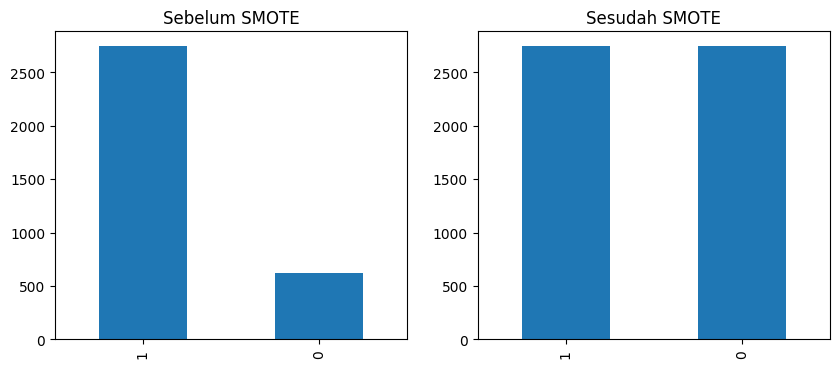

In [51]:
import matplotlib.pyplot as plt

before = pd.Series(y_train).value_counts()
after = pd.Series(y_train_smote).value_counts()

fig, axes = plt.subplots(1,2, figsize=(10,4))

before.plot(kind='bar', ax=axes[0], title='Sebelum SMOTE')
after.plot(kind='bar', ax=axes[1], title='Sesudah SMOTE')

plt.show()

In [52]:
from scipy import sparse

sparse.save_npz("07_X_train_smote.npz", X_train_smote)

pd.DataFrame({'label_train_smote': y_train_smote}).to_csv(
    "07_y_train_smote.csv", index=False, encoding="utf-8-sig"
)

print("Data SMOTE berhasil disimpan")

Data SMOTE berhasil disimpan


## Machine Learning Models

The project compares three classification models:
- Support Vector Machine (SVM)
- CatBoost
- XGBoost

**Support Vector Machine**

In [53]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [55]:
svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train_smote, y_train_smote)

SVC(kernel='linear', random_state=42)

In [56]:
y_pred_svm = svm_model.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy)

Accuracy: 0.9430604982206405


In [58]:
precision = precision_score(y_test, y_pred_svm)
print("Precision:", precision)

Precision: 0.9747023809523809


In [59]:
recall = recall_score(y_test, y_pred_svm)
print("Recall:", recall)

Recall: 0.9548104956268222


In [60]:
f1 = f1_score(y_test, y_pred_svm)
print("F1-Score:", f1)

F1-Score: 0.9646539027982327


In [61]:
cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[140  17]
 [ 31 655]]


In [62]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       157
           1       0.97      0.95      0.96       686

    accuracy                           0.94       843
   macro avg       0.90      0.92      0.91       843
weighted avg       0.95      0.94      0.94       843



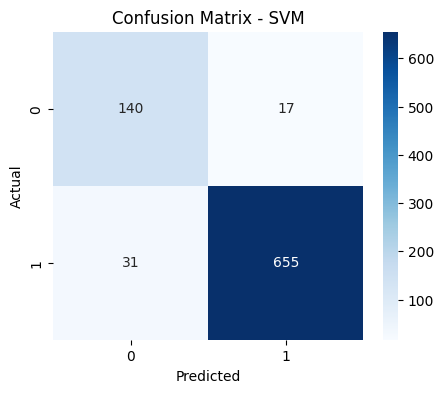

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
import pandas as pd

svm_result = pd.DataFrame({
    'Model': ['SVM'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
})

svm_result.to_csv("08_hasil_svm.csv", index=False, encoding="utf-8-sig")

print("Hasil SVM berhasil disimpan")

Hasil SVM berhasil disimpan


**Categorical Boosting**

In [65]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [66]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [67]:
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    verbose=0,
    random_state=42
)

cat_model.fit(X_train_smote, y_train_smote)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, loss_function='Logloss', random_state=42, verbose=0)

In [68]:
y_pred_cat = cat_model.predict(X_test)

In [69]:
import numpy as np

y_pred_cat = np.array(y_pred_cat).flatten()
print(y_pred_cat[:10])

[0 1 1 1 1 1 1 0 1 1]


In [70]:
accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)

print("Accuracy :", accuracy_cat)
print("Precision:", precision_cat)
print("Recall   :", recall_cat)
print("F1-Score :", f1_cat)

Accuracy : 0.9264531435349941
Precision: 0.9785276073619632
Recall   : 0.9300291545189504
F1-Score : 0.953662182361734


In [71]:
cm_cat = confusion_matrix(y_test, y_pred_cat)
print("Confusion Matrix:\n", cm_cat)

Confusion Matrix:
 [[143  14]
 [ 48 638]]


In [72]:
print(classification_report(y_test, y_pred_cat))

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       157
           1       0.98      0.93      0.95       686

    accuracy                           0.93       843
   macro avg       0.86      0.92      0.89       843
weighted avg       0.94      0.93      0.93       843



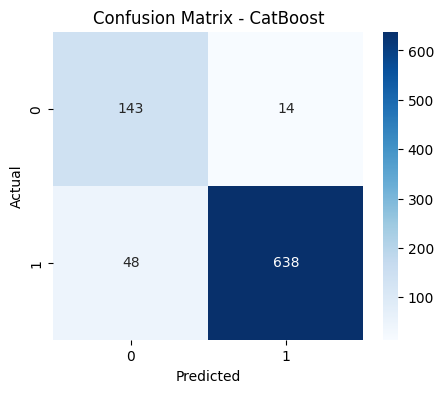

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [74]:
import pandas as pd

cat_result = pd.DataFrame({
    'Model': ['CatBoost'],
    'Accuracy': [accuracy_cat],
    'Precision': [precision_cat],
    'Recall': [recall_cat],
    'F1-Score': [f1_cat]
})

cat_result.to_csv("09_hasil_catboost.csv", index=False, encoding="utf-8-sig")
print("Hasil CatBoost berhasil disimpan")

Hasil CatBoost berhasil disimpan


**Extreme Gradient Boosting**

In [75]:
!pip install xgboost -q

In [76]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

In [77]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [78]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.array(y_pred_xgb).flatten()

print(y_pred_xgb[:10])

[0 1 1 1 1 1 1 0 1 1]


In [79]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1-Score :", f1_xgb)

Accuracy : 0.9383155397390273
Precision: 0.9689349112426036
Recall   : 0.9548104956268222
F1-Score : 0.9618208516886931


In [80]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm_xgb)

Confusion Matrix:
 [[136  21]
 [ 31 655]]


In [81]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.97      0.95      0.96       686

    accuracy                           0.94       843
   macro avg       0.89      0.91      0.90       843
weighted avg       0.94      0.94      0.94       843



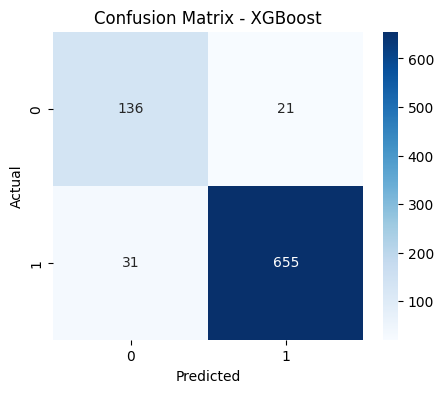

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [83]:
import pandas as pd

xgb_result = pd.DataFrame({
    'Model': ['XGBoost'],
    'Accuracy': [accuracy_xgb],
    'Precision': [precision_xgb],
    'Recall': [recall_xgb],
    'F1-Score': [f1_xgb]
})

xgb_result.to_csv("10_hasil_xgboost.csv", index=False, encoding="utf-8-sig")
print("Hasil XGBoost berhasil disimpan")

Hasil XGBoost berhasil disimpan


**Result**

In [84]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['SVM', 'CatBoost', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_cat, accuracy_xgb],
    'Precision': [precision, precision_cat, precision_xgb],
    'Recall': [recall, recall_cat, recall_xgb],
    'F1-Score': [f1, f1_cat, f1_xgb]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.943060,0.974702,0.954810,0.964654
1,CatBoost,0.926453,0.978528,0.930029,0.953662
2,XGBoost,0.938316,0.968935,0.954810,0.961821


In [85]:
results_sorted = results.sort_values(by='Accuracy', ascending=False)
results_sorted

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.943060,0.974702,0.954810,0.964654
2,XGBoost,0.938316,0.968935,0.954810,0.961821
1,CatBoost,0.926453,0.978528,0.930029,0.953662


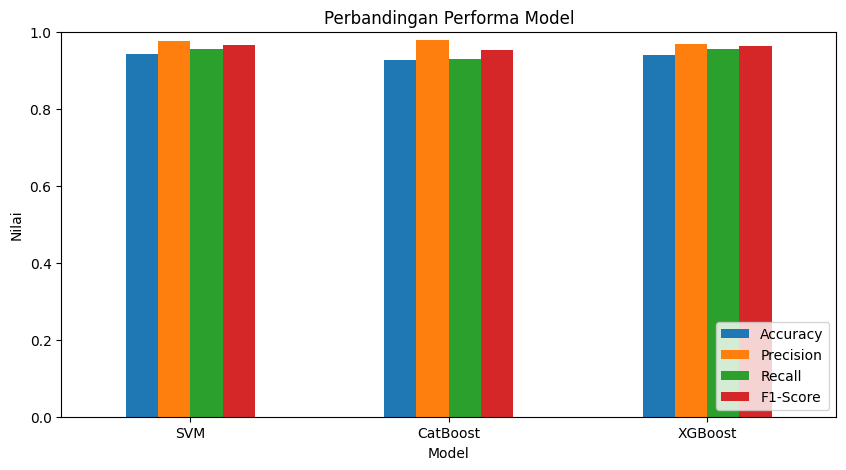

In [86]:
import matplotlib.pyplot as plt

results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Perbandingan Performa Model')
plt.ylabel('Nilai')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [87]:
results.to_csv("11_perbandingan_model.csv", index=False, encoding="utf-8-sig")

from google.colab import files
files.download("11_perbandingan_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Results

SVM achieved the best performance with:
- Accuracy: 94%
- Precision: 96%
- Recall: 95%
- F1-Score: 96%

## Key Insights

- SVM achieved the highest overall performance among the tested models.
- SMOTE significantly improved minority class classification.
- Positive reviews dominate the dataset, indicating generally positive user perception toward the TransJakarta application.
- Machine learning models successfully classified user sentiment with high accuracy.

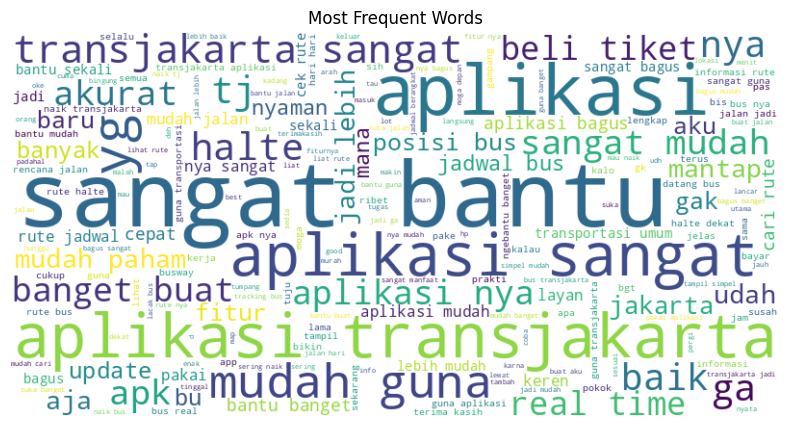

In [88]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['final_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words')
plt.show()